In [1]:
from heaict.mobo.utility import find_pareto_front
from heaict.cats.problem import round_preserve_sum
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np
import pickle
import pandas
import shap
import os

# read in data

In [2]:
pft_HEA={}
pfs_HEA={}
Y_HEA={}
X_HEA={}

for sys in ['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']:
    X = np.load(os.path.join(f'Data/XY_data/HEA_mobo2/', sys, 'X.npy'))
    Y = np.load(os.path.join(f'Data/XY_data/HEA_mobo2/', sys, 'Y.npy'))
    X_HEA[sys]=X
    Y_HEA[sys]=Y
    
    pY, pfi = find_pareto_front(Y)
    pfront = np.load(os.path.join(f'Data/XY_data/HEA_mobo2/', sys, 'pfront.npy'))
    pft_HEA[sys]=pY
    pfs_HEA[sys]=pfront
    
pft_HEI={}
pfs_HEI={}
Y_HEI={}
X_HEI={}

for sys in ['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']:
    X = np.load(os.path.join(f'Data/XY_data/HEI_mobo2/', sys, 'X.npy'))
    Y = np.load(os.path.join(f'Data/XY_data/HEI_mobo2/', sys, 'Y.npy'))
    X_HEI[sys]=X
    Y_HEI[sys]=Y
    
    pY, pfi = find_pareto_front(Y)
    pfront = np.load(os.path.join(f'Data/XY_data/HEI_mobo2/', sys, 'pfront.npy'))
    pft_HEI[sys]=pY
    pfs_HEI[sys]=pfront

# Figure 4a

In [3]:
max_lnvnr=0
for i, dic in enumerate([pft_HEA, pft_HEI]):
    for sys in ['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']:
        if np.max(dic[sys][:, 0]) > max_lnvnr:
            max_lnvnr = np.max(dic[sys][:, 0])
            print(i, sys, max_lnvnr)

0 MoMn 1.6915689028118113
0 MoFe 2.516826083154381
0 MoCo 4.342297591713721
0 MnRu 4.492826320876246
0 MnCo 8.594577812293045
0 FeCo 8.6447239812585
1 MnRu 8.694464783993535
1 FeRu 9.03903159982341


In [4]:
np.exp(-9.03903159982341)

0.00011868571608905117

In [5]:
-np.log(0.00011868571608905117*1500)

1.7258112127331087

In [3]:
colors={
    'MoMn': '#F7A6AC',
    'MoFe': '#F7B7D2',
    'MoRu': '#EEC186',
    'MoCo': '#EEF0A7',
    'MnFe': '#B2DF8A',
    'MnRu': '#00A664',
    'MnCo': '#4C6C43',
    'FeRu': '#B8E5FA',
    'FeCo': '#5086C4',
    'RuCo': '#7C7CBA',
}

Text(3.2, -0.7, ' Ni$_{30}$Pd$_{6}$Cu$_{14}$Mo$_{23}$Mn$_{27}$\n(Ni$_{20}$Pd$_{7}$Cu$_{18}$Mo$_{30}$Mn$_{25}$)$_{3c}$\n(Ni$_{60}$Pd$_{4}$Cu$_{2}$Mo$_{2}$Mn$_{32}$)$_{1a}$')

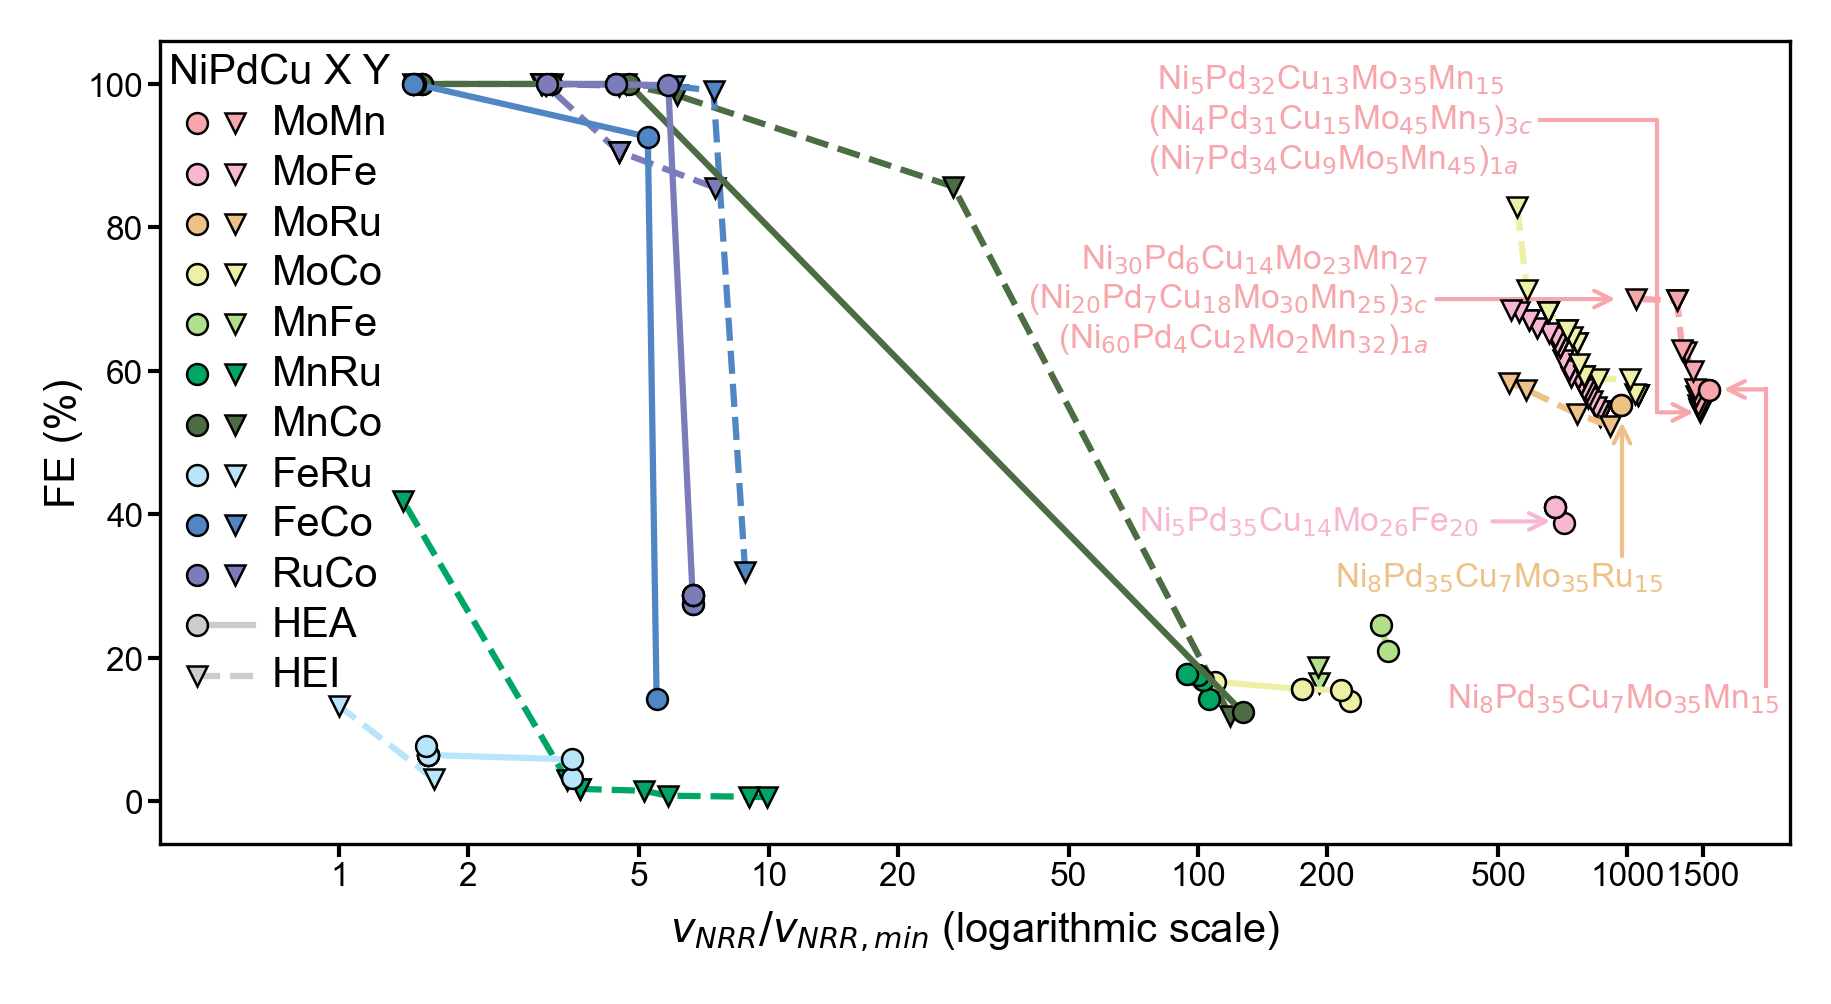

In [4]:
plt.rc('font',family='Arial')
fig=plt.figure(figsize=(15/2.54, 8/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

# Figure 1
ax1=fig.add_axes([1.1/15, 1.1/8, 13.8/15, 6.8/8])
ax1.set_zorder(2)
ax1.patch.set_alpha(0.0)
ax1.tick_params(length=3,width=1,labelsize=8,pad=1)

for sys in ['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']:
    ax1.plot(pft_HEA[sys][:, 0], pft_HEA[sys][:, 1], c=colors[sys], ls='-', marker='o',  markersize=5, markeredgecolor='k', markeredgewidth=0.6, zorder=2)
    
for sys in ['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']:
    ax1.plot(pft_HEI[sys][:, 0], pft_HEI[sys][:, 1], c=colors[sys], ls='--', marker='v', markersize=5,markeredgecolor='k', markeredgewidth=0.6, zorder=1)

ax1.set_xlabel('$v_{NRR} / v_{NRR, min}$ (logarithmic scale)', fontsize=10)
ax1.set_ylabel('FE (%)', fontsize=10, labelpad=1)
ax1.set_ylim(0.06, -1.06)
ax1.set_yticks([-1, -0.8, -0.6, -0.4, -0.2, 0])
ax1.set_yticklabels([100, 80, 60, 40, 20, 0])
ax1.set_xlim(10, 1.26)
ax1.set_xticks([9.039, 8.346, 7.430, 6.736, 6.043, 5.127, 4.434, 3.741, 2.824, 2.131, 1.726])
ax1.set_xticklabels([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500])

ax1.text(9.95,-1,'NiPdCu X Y', fontsize=10)
for i, sys in enumerate(['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']):
    ax1.plot([9.8], [-1.015+0.07*(i+1)], c=colors[sys], ls='-', marker='o', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
    ax1.plot([9.6], [-1.015+0.07*(i+1)], c=colors[sys], ls='--', marker='v', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
    ax1.text(9.4, -1.015+0.07*(i+1), sys, fontsize=10, va='center')
ax1.plot([9.8, 9.5], [-1.015+0.07*(10+1), -1.015+0.07*(10+1)], c='#CCCCCC', ls='-', )
ax1.plot([9.8], [-1.015+0.07*(10+1)], c='#CCCCCC', ls='-', marker='o', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
ax1.text(9.4, -1.015+0.07*(10+1), 'HEA', fontsize=10, ha='left', va='center')
ax1.plot([9.8, 9.5], [-1.015+0.07*(11+1), -1.015+0.07*(11+1)], c='#CCCCCC', ls='--', )
ax1.plot([9.8], [-1.015+0.07*(11+1)], c='#CCCCCC', ls='-', marker='v', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
ax1.text(9.4, -1.015+0.07*(11+1), 'HEI', fontsize=10, ha='left', va='center')

arrow = FancyArrowPatch((1.36, -0.574), (1.66, -0.574), arrowstyle='->', mutation_scale=10, color=colors['MoMn'], lw=1)
ax1.add_patch(arrow)
ax1.plot([1.39, 1.39], [-0.574, -0.16], c=colors['MoMn'], lw=1, zorder=0)
ax1.text(3.1, -0.13, 'Ni$_8$Pd$_{35}$Cu$_{7}$Mo$_{35}$Mn$_{15}$', fontsize=8, ha='left', c=colors['MoMn'])
arrow = FancyArrowPatch((2.16, -0.33), (2.16, -0.54), arrowstyle='->', mutation_scale=10, color=colors['MoRu'], lw=1)
ax1.add_patch(arrow)
ax1.text(3.7, -0.3, 'Ni$_8$Pd$_{35}$Cu$_{7}$Mo$_{35}$Ru$_{15}$', fontsize=8, ha='left', c=colors['MoRu'])
arrow = FancyArrowPatch((2.9, -0.39), (2.5, -0.39), arrowstyle='->', mutation_scale=10, color=colors['MoFe'], lw=1)
ax1.add_patch(arrow)
ax1.text(4.75, -0.39, 'Ni$_5$Pd$_{35}$Cu$_{14}$Mo$_{26}$Fe$_{20}$', fontsize=8, ha='left', c=colors['MoFe'], va='center')

arrow = FancyArrowPatch((2.0, -0.542), (1.73, -0.542), arrowstyle='->', mutation_scale=10, color=colors['MoMn'], lw=1)
ax1.add_patch(arrow)
ax1.plot([1.97, 1.97, 2.6], [-0.542, -0.95, -0.95], c=colors['MoMn'], lw=1, zorder=0)
ax1.text(4.7, -0.95, ' Ni$_{5}$Pd$_{32}$Cu$_{13}$Mo$_{35}$Mn$_{15}$\n(Ni$_4$Pd$_{31}$Cu$_{15}$Mo$_{45}$Mn$_{5}$)$_{3c}$\n(Ni$_{7}$Pd$_{34}$Cu$_{9}$Mo$_{5}$Mn$_{45}$)$_{1a}$', fontsize=8, ha='left', c=colors['MoMn'], va='center')
arrow = FancyArrowPatch((3.2, -0.70), (2.15, -0.70), arrowstyle='->', mutation_scale=10, color=colors['MoMn'], lw=1, zorder=0)
ax1.add_patch(arrow)
ax1.text(3.2, -0.7, ' Ni$_{30}$Pd$_{6}$Cu$_{14}$Mo$_{23}$Mn$_{27}$\n(Ni$_{20}$Pd$_{7}$Cu$_{18}$Mo$_{30}$Mn$_{25}$)$_{3c}$\n(Ni$_{60}$Pd$_{4}$Cu$_{2}$Mo$_{2}$Mn$_{32}$)$_{1a}$', fontsize=8, ha='right', c=colors['MoMn'], va='center')

# Figure 4c

In [5]:
def get_sys_X_Y(sys, Xdata=X_HEA, Ydata=Y_HEA):
    X=Xdata[sys]
    X=np.column_stack([X, (1-np.sum(X,axis=1)).reshape(-1, 1)])
    XX = []
    for x in X:
        XX.append(round_preserve_sum(x))
    XX=np.array(XX)
    Y=Ydata[sys]
    unique_rows, indices = np.unique(XX.view(XX.dtype.descr * XX.shape[1]), return_index=True)
    XX = XX[indices, :]
    Y =Y[indices, :]
    return XX, Y

In [6]:
shap_objs_lnv={}
for sys in ['MoMn', 'MoRu', 'MoFe']:
    X, Y = get_sys_X_Y(sys)
    model = xgb.XGBRegressor()
    model.fit(X, -1*Y[:, 0])
    explainer = shap.Explainer(model)
    shap_obj = explainer(X)
    shap_objs_lnv[sys] = shap_obj

shap_objs_FE={}
for sys in ['MoMn', 'MoRu', 'MoFe']:
    X, Y = get_sys_X_Y(sys)
    model = xgb.XGBRegressor()
    model.fit(X, -100*Y[:, 1])
    explainer = shap.Explainer(model)
    shap_obj = explainer(X)
    shap_objs_FE[sys] = shap_obj

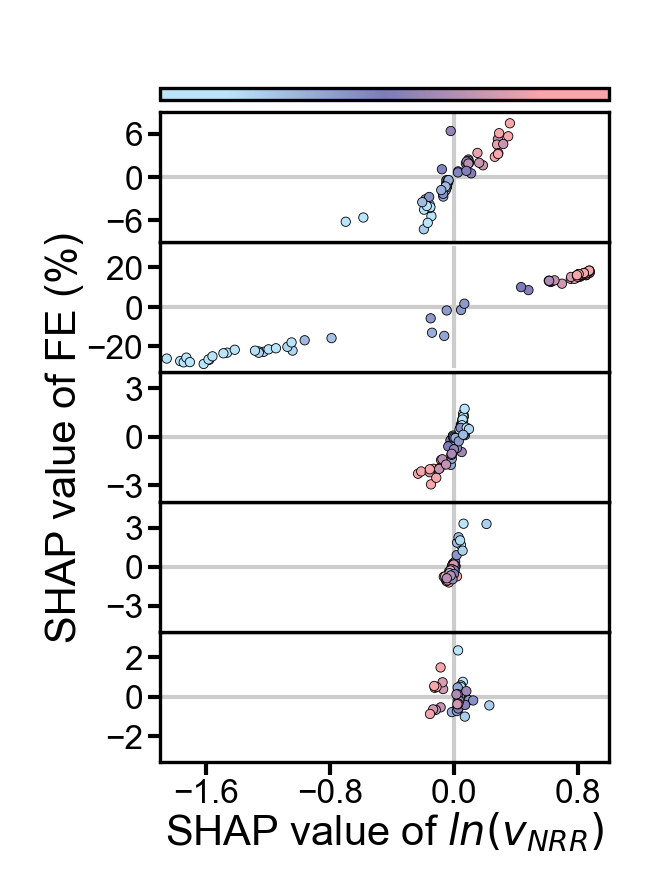

In [7]:
plt.rc('font',family='Arial')
fig=plt.figure(figsize=(5/2.54, 7/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)
cmap_fv=LinearSegmentedColormap.from_list(name='xx', colors=list(zip([0, 0.15, 0.5, 0.85, 1], ['#B8E5FA', '#B8E5FA', '#7C7CBA', '#F7A6AC', '#F7A6AC'])))

sys = 'MoMn'
all_xlim=(-1.9, 1.0) #*********

ax1=fig.add_axes([1.1/5, 0.8/7, 3.8/5, 1.1/7]); ax1.tick_params(length=3,width=1,labelsize=8,pad=1)
ax1.set_xlabel('SHAP value of $ln(v_{NRR})$', fontsize=10, labelpad=0)
ax1.scatter(shap_objs_lnv[sys].values[:, 0], shap_objs_FE[sys].values[:, 0], c=shap_objs_FE[sys].data[:, 0], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax1.get_ylim()
ax1.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax1.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax1.set_xlim(*all_xlim); ax1.set_ylim(*ylim)
ax1.set_yticks([-2, 0, 2]); ax1.set_ylim(-3.3, 3.3) #*********
ax1.set_xticks([-1.6, -0.8, 0, 0.8]) #********* 

ax2=fig.add_axes([1.1/5, 1.9/7, 3.8/5, 1.1/7]); ax2.tick_params(length=3,width=1,labelsize=8,pad=1); ax2.set_xticks([])
ax2.scatter(shap_objs_lnv[sys].values[:, 1], shap_objs_FE[sys].values[:, 1], c=shap_objs_FE[sys].data[:, 1], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax2.get_ylim()
ax2.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax2.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax2.set_xlim(*all_xlim); ax2.set_ylim(*ylim)
ax2.set_yticks([3, 0, -3]); ax2.set_ylim(-5,5) #*********

ax3=fig.add_axes([1.1/5, 3.0/7, 3.8/5, 1.1/7]); ax3.tick_params(length=3,width=1,labelsize=8,pad=1); ax3.set_xticks([])
ax3.scatter(shap_objs_lnv[sys].values[:, 2], shap_objs_FE[sys].values[:, 2], c=shap_objs_FE[sys].data[:, 2], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax3.get_ylim()
ax3.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax3.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax3.set_xlim(*all_xlim); ax3.set_ylim(*ylim)
ax3.set_yticks([-3, 0, 3]); ax3.set_ylim(-4, 4)
ax3.set_ylabel('SHAP value of FE (%)', fontsize=10, labelpad=5)

ax4=fig.add_axes([1.1/5, 4.1/7, 3.8/5, 1.1/7]); ax4.tick_params(length=3,width=1,labelsize=8,pad=1); ax4.set_xticks([])
ax4.scatter(shap_objs_lnv[sys].values[:, 3], shap_objs_FE[sys].values[:, 3], c=shap_objs_FE[sys].data[:, 3], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax4.get_ylim()
ax4.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax4.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax4.set_xlim(*all_xlim); ax4.set_ylim(*ylim)
ax4.set_yticks([-20, 0, 20]); ax4.set_ylim(-33, 33) #*********

ax5=fig.add_axes([1.1/5, 5.2/7, 3.8/5, 1.1/7]); ax5.tick_params(length=3,width=1,labelsize=8,pad=1); ax5.set_xticks([])
ax5.scatter(shap_objs_lnv[sys].values[:, 4], shap_objs_FE[sys].values[:, 4], c=shap_objs_FE[sys].data[:, 4], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax5.get_ylim()
ax5.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax5.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='-', zorder=0)
ax5.set_xlim(*all_xlim); ax5.set_ylim(*ylim)
ax5.set_yticks([-6, 0, 6]); ax5.set_ylim(-9, 9) #*********

ax6=fig.add_axes([1.1/5, 6.4/7, 3.8/5, 0.1/7])
cb = ColorbarBase(ax6, cmap=cmap_fv, orientation='horizontal')
cb.set_ticks([])

# Figure 4c

In [8]:
cus_cmap=LinearSegmentedColormap.from_list(name='xx', colors=list(zip([0, 0.33, 0.67, 1], ['#B8E5FA', '#B2DBB9', '#EEC186', '#F7A6AC'])))

In [9]:
XN = {}; YN = {}
XP = {}; YP = {}
for sys in ['MoMn', 'MoRu', 'MoFe']:
    X, Y = get_sys_X_Y(sys)
    py, pi = find_pareto_front(Y)
    XN[sys] = []; XP[sys] = []; YN[sys] = []; YP[sys] = []
    for i, x in enumerate(X):
        if i not in pi:
            XN[sys].append(x); YN[sys].append([np.exp(-Y[i][0]+9.03903159982341), -100*Y[i][1]])
        else:
            XP[sys].append(x); YP[sys].append([np.exp(-Y[i][0]+9.03903159982341), -100*Y[i][1]])
    XN[sys] = np.array(XN[sys]); XP[sys] = np.array(XP[sys]); YN[sys] = np.array(YN[sys]); YP[sys] = np.array(YP[sys])
YV = np.vstack([YN['MoMn'], YN['MoRu'], YN['MoFe'], YP['MoMn'], YP['MoRu'], YP['MoFe']])
vmin = np.min(YV[:, 0]); vmax = np.max(YV[:, 0])
smaxV = np.max(YV[:, 1]); sminV = np.min(YV[:, 1]); LsV = smaxV - sminV
smin = 3; smax = 10; Ls = smax - smin

In [10]:
def ternary_to_cartesian(a, b, c, width=2.0, height=np.sqrt(3)):
    x = width * (c+b/2)
    y = height * b
    return x, y
def find_multiple_of_5(start, end):
    first = start + (5 - start % 5) % 5
    last = end - (end % 5)
    if first > end:
        return []
    return list(range(first, last + 1, 5))

In [9]:
print(vmin, vmax, sminV, smaxV)

3.19632338584363 1552.252990826331 0.43464285135336916 57.38615534846674


In [11]:
vmin = 0; vmax = 1600

Text(0.5599999999999999, 0.9571428571428572, 'Dominated samples')

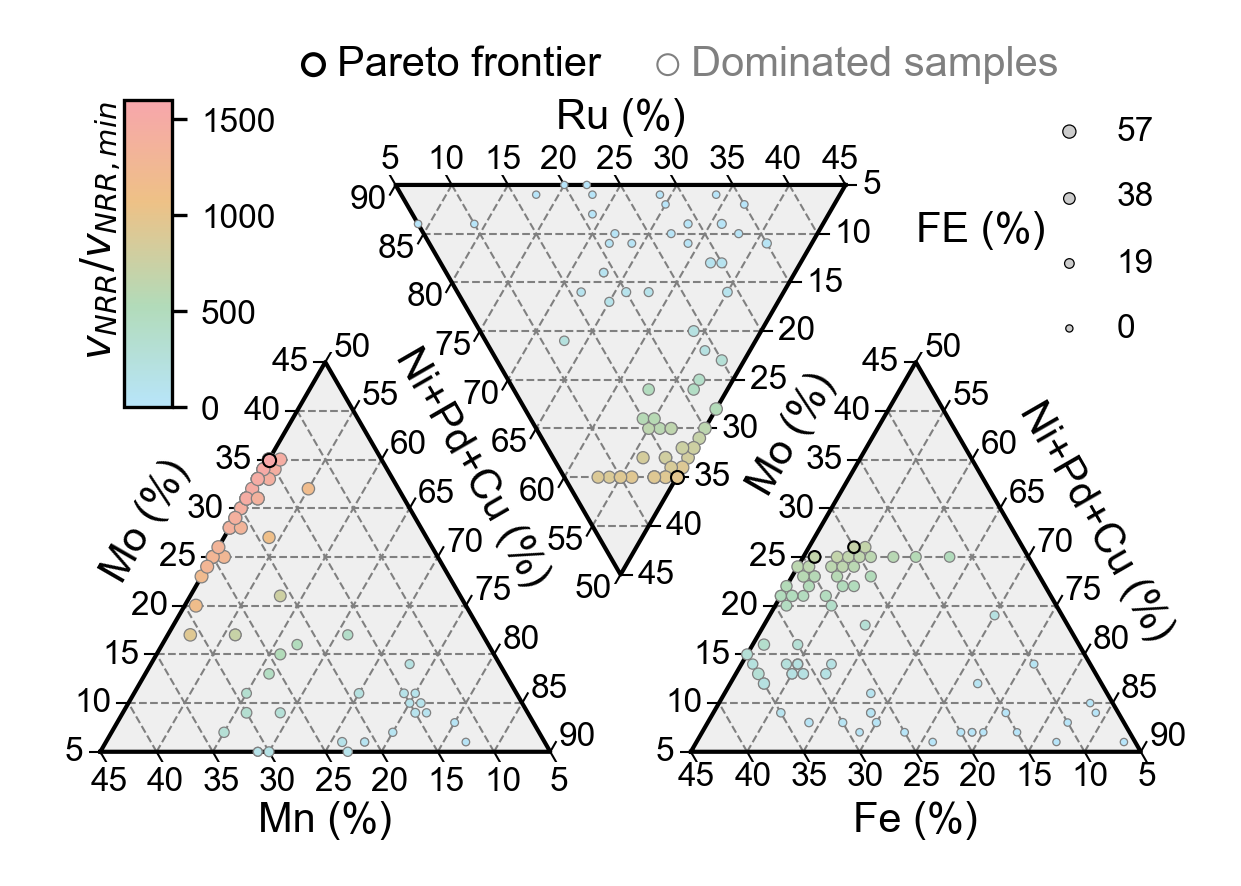

In [12]:
plt.rc('font',family='Arial')
fig=plt.figure(figsize=(10/2.54, 7/2.54), dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

tl=2
th=np.sqrt(3)
# ax1 ===================================================
ax1=fig.add_axes([0.5/10, 0.8/7, 4/10, (4*np.sqrt(3)/2)/7]);ax1.patch.set_alpha(0.0)
ax1.set_xticks([]);ax1.set_yticks([]);ax1.axis('off')
ax1.set_xlim(-tl*0.1,tl*1.1);ax1.set_ylim(-th*0.1,th*1.1)
# ax1.plot([0, tl, tl/2, 0], [0, 0, th, 0], c='k', lw=1)
# scatter
sys = 'MoMn'
pointsN = []
for i, x in enumerate(XN[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsN.append(ternary_to_cartesian(a, b, c))
pointsP = []
for i, x in enumerate(XP[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsP.append(ternary_to_cartesian(a, b, c))
pointsN = np.array(pointsN); pointsP = np.array(pointsP)
ax1.scatter(pointsN[:, 0], pointsN[:, 1], s=smin+(YN[sys][:,1]-sminV)/LsV*Ls, c=YN[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='grey', lw=0.3, alpha=1, zorder=10)
ax1.scatter(pointsP[:, 0], pointsP[:, 1], s=smin+(YP[sys][:,1]-sminV)/LsV*Ls, c=YP[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='k', lw=0.5, alpha=1, zorder=11)
# draw line
itl=0.40; ia_up=0.45; ib_low=0.05; sp=[2-(2*ia_up)-ib_low, ib_low*np.sqrt(3)]
ax1.plot([0+sp[0], tl*itl+sp[0], tl/2*itl+sp[0], 0+sp[0]], [0+sp[1], 0+sp[1], th*itl+sp[1], 0+sp[1]], c='k', lw=1, zorder=6)
ia_up = ia_up; ia_low = ia_up - itl; ib_low = ib_low; ib_up = ib_low + itl; ic_up = 1-(ib_low+ia_low); ic_low = ic_up - itl
a5i = find_multiple_of_5(int(ia_low*100), int(ia_up*100))
for i in a5i:
    aa = itl-(i/100-ia_low)
    ax1.plot([sp[0]+aa*tl, sp[0]+aa], [sp[1], sp[1]+aa*th], lw=0.5, ls='--', c='grey')
    ax1.plot([sp[0]+aa*tl, sp[0]+aa*tl+0.01], [sp[1], sp[1]-0.01*th], lw=0.5, c='k')
    ax1.text(sp[0]+aa*tl+0.015, sp[1]-0.015*th, str(i), fontsize=8, ha='center', va='top')
b5i = find_multiple_of_5(int(ib_low*100), int(ib_up*100))
for i in b5i:
    bb = i/100 - ib_low
    ax1.plot([sp[0]+bb, sp[0]+tl*itl-bb], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, ls='--', c='grey')
    ax1.plot([sp[0]+bb, sp[0]+bb-tl*0.01], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, c='k')
    ax1.text(sp[0]+bb-tl*0.015, sp[1]+th*bb, str(i), ha='right', va='center', fontsize=8)
c5i = find_multiple_of_5(int(ic_low*100), int(ic_up*100))
for i in c5i:
    cc1 = i/100 - ic_low; cc2 = ic_up - i/100
    ax1.plot([sp[0]+cc1*tl, sp[0]+cc1*tl+cc2], [sp[1], sp[1]+th*cc2], lw=0.5, ls='--', c='grey')
    ax1.plot([sp[0]+cc1*tl+cc2, sp[0]+cc1*tl+cc2+0.01*tl/2], [sp[1]+th*cc2, sp[1]+th*(cc2+0.01)], lw=0.5, c='k')
    ax1.text(sp[0]+cc1*tl+cc2+0.015*tl/2, sp[1]+th*(cc2+0.015), str(i), fontsize=8, ha='left', va='center')
# other
ax1.set_xlim(sp[0]-tl*0.01, sp[0]+tl*0.41)
ax1.set_ylim(sp[1]-th*0.01, sp[1]+th*0.41)
ax1.text(sp[0]+tl*itl/2, sp[1]-th*0.05, 'Mn (%)', fontsize=10, ha='center', va='top')
ax1.text(sp[0]+tl*itl/4-th*0.055*tl/th-0.01, sp[1]+th*itl/2+th*0.055/th+0.01, 'Mo (%)', fontsize=10, ha='center', va='center', rotation=60)
ax1.text(sp[0]+tl*itl*3/4+th*0.05*tl/th-0.04, sp[1]+th*itl/2+th*0.05/th+0.11, 'Ni+Pd+Cu (%)', fontsize=10, ha='center', va='center', rotation=-60)
ax1.add_patch(Polygon([[0+sp[0], 0+sp[1]], [tl*itl+sp[0], 0+sp[1]], [tl/2*itl+sp[0], th*itl+sp[1]]], facecolor='#CCCCCC', alpha=0.3, linewidth=0))

# ax2 ===================================================
ax2=fig.add_axes([3/10, 2.3/7, 4/10, (4*np.sqrt(3)/2)/7]);ax2.patch.set_alpha(0.0)
ax2.set_xticks([]);ax2.set_yticks([]);ax2.axis('off')
ax2.set_xlim(-tl*0.1,tl*1.1);ax2.set_ylim(-th*0.1,th*1.1)
# ax2.plot([0, tl, tl/2, 0], [0, 0, th, 0], c='k', lw=1)
# scatter
sys = 'MoRu'
pointsN = []
for i, x in enumerate(XN[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsN.append(ternary_to_cartesian(a, b, c))
pointsP = []
for i, x in enumerate(XP[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsP.append(ternary_to_cartesian(a, b, c))
pointsN = np.array(pointsN); pointsP = np.array(pointsP)
ax2.scatter(pointsN[:, 0], pointsN[:, 1], s=smin+(YN[sys][:,1]-sminV)/LsV*Ls, c=YN[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='grey', lw=0.3, alpha=1, zorder=10)
ax2.scatter(pointsP[:, 0], pointsP[:, 1], s=smin+(YP[sys][:,1]-sminV)/LsV*Ls, c=YP[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='k', lw=0.5, alpha=1, zorder=11)
# draw line
itl=0.40; ia_up=0.45; ib_low=0.05; sp=[2-(2*ia_up)-ib_low, ib_low*np.sqrt(3)]
ax2.plot([0+sp[0], tl*itl+sp[0], tl/2*itl+sp[0], 0+sp[0]], [0+sp[1], 0+sp[1], th*itl+sp[1], 0+sp[1]], c='k', lw=1, zorder=6)
ia_up = ia_up; ia_low = ia_up - itl; ib_low = ib_low; ib_up = ib_low + itl; ic_up = 1-(ib_low+ia_low); ic_low = ic_up - itl
a5i = find_multiple_of_5(int(ia_low*100), int(ia_up*100))
for i in a5i:
    aa = itl-(i/100-ia_low)
    ax2.plot([sp[0]+aa*tl, sp[0]+aa], [sp[1], sp[1]+aa*th], lw=0.5, ls='--', c='grey')
    ax2.plot([sp[0]+aa*tl, sp[0]+aa*tl+0.01], [sp[1], sp[1]-0.01*th], lw=0.5, c='k')
    ax2.text(sp[0]+aa*tl+0.01, sp[1]-0.01*th, str(i), fontsize=8, ha='center', va='bottom')
b5i = find_multiple_of_5(int(ib_low*100), int(ib_up*100))
for i in b5i:
    bb = i/100 - ib_low
    ax2.plot([sp[0]+bb, sp[0]+tl*itl-bb], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, ls='--', c='grey')
    ax2.plot([sp[0]+bb, sp[0]+bb-tl*0.01], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, c='k')
    ax2.text(sp[0]+bb-tl*0.015, sp[1]+th*bb, str(i), ha='left', va='center', fontsize=8)
c5i = find_multiple_of_5(int(ic_low*100), int(ic_up*100))
for i in c5i:
    cc1 = i/100 - ic_low; cc2 = ic_up - i/100
    ax2.plot([sp[0]+cc1*tl, sp[0]+cc1*tl+cc2], [sp[1], sp[1]+th*cc2], lw=0.5, ls='--', c='grey')
    ax2.plot([sp[0]+cc1*tl+cc2, sp[0]+cc1*tl+cc2+0.01*tl/2], [sp[1]+th*cc2, sp[1]+th*(cc2+0.01)], lw=0.5, c='k')
    ax2.text(sp[0]+cc1*tl+cc2+0.015*tl/2, sp[1]+th*(cc2+0.015), str(i), fontsize=8, ha='right', va='center')
# other
ax2.set_xlim(sp[0]+tl*0.41, sp[0]-tl*0.01)
ax2.set_ylim(sp[1]+th*0.41, sp[1]-th*0.01)
ax2.text(sp[0]+tl*itl/2, sp[1]-th*0.09, 'Ru (%)', fontsize=10, ha='center', va='top')
# ax2.text(sp[0]+tl*itl/4-th*0.05*tl/th, sp[1]+th*itl/2+th*0.05/th, 'Mo (%)', fontsize=8, ha='center', va='center', rotation=60)
# ax2.text(sp[0]+tl*itl*3/4+th*0.05*tl/th, sp[1]+th*itl/2+th*0.05/th, 'Ni+Pd+Cu (%)', fontsize=8, ha='center', va='center', rotation=-60)
ax2.add_patch(Polygon([[0+sp[0], 0+sp[1]], [tl*itl+sp[0], 0+sp[1]], [tl/2*itl+sp[0], th*itl+sp[1]]], facecolor='#CCCCCC', alpha=0.3, linewidth=0))

# ax3 ===================================================
ax3=fig.add_axes([5.5/10, 0.8/7, 4/10, (4*np.sqrt(3)/2)/7]);ax3.patch.set_alpha(0.0)
ax3.set_xticks([]);ax3.set_yticks([]);ax3.axis('off')
ax3.set_xlim(-tl*0.1,tl*1.1);ax3.set_ylim(-th*0.1,th*1.1)
# ax2.plot([0, tl, tl/2, 0], [0, 0, th, 0], c='k', lw=1)
# scatter
sys = 'MoFe'
pointsN = []
for i, x in enumerate(XN[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsN.append(ternary_to_cartesian(a, b, c))
pointsP = []
for i, x in enumerate(XP[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsP.append(ternary_to_cartesian(a, b, c))
pointsN = np.array(pointsN); pointsP = np.array(pointsP)
ax3.scatter(pointsN[:, 0], pointsN[:, 1], s=smin+(YN[sys][:,1]-sminV)/LsV*Ls, c=YN[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='grey', lw=0.3, alpha=1, zorder=10)
ax3.scatter(pointsP[:, 0], pointsP[:, 1], s=smin+(YP[sys][:,1]-sminV)/LsV*Ls, c=YP[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='k', lw=0.5, alpha=1, zorder=11)
# draw line
itl=0.40; ia_up=0.45; ib_low=0.05; sp=[2-(2*ia_up)-ib_low, ib_low*np.sqrt(3)]
ax3.plot([0+sp[0], tl*itl+sp[0], tl/2*itl+sp[0], 0+sp[0]], [0+sp[1], 0+sp[1], th*itl+sp[1], 0+sp[1]], c='k', lw=1, zorder=6)
ia_up = ia_up; ia_low = ia_up - itl; ib_low = ib_low; ib_up = ib_low + itl; ic_up = 1-(ib_low+ia_low); ic_low = ic_up - itl
a5i = find_multiple_of_5(int(ia_low*100), int(ia_up*100))
for i in a5i:
    aa = itl-(i/100-ia_low)
    ax3.plot([sp[0]+aa*tl, sp[0]+aa], [sp[1], sp[1]+aa*th], lw=0.5, ls='--', c='grey')
    ax3.plot([sp[0]+aa*tl, sp[0]+aa*tl+0.01], [sp[1], sp[1]-0.01*th], lw=0.5, c='k')
    ax3.text(sp[0]+aa*tl+0.01, sp[1]-0.01*th, str(i), fontsize=8, ha='center', va='top')
b5i = find_multiple_of_5(int(ib_low*100), int(ib_up*100))
for i in b5i:
    bb = i/100 - ib_low
    ax3.plot([sp[0]+bb, sp[0]+tl*itl-bb], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, ls='--', c='grey')
    ax3.plot([sp[0]+bb, sp[0]+bb-tl*0.01], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, c='k')
    ax3.text(sp[0]+bb-tl*0.015, sp[1]+th*bb, str(i), ha='right', va='center', fontsize=8)
c5i = find_multiple_of_5(int(ic_low*100), int(ic_up*100))
for i in c5i:
    cc1 = i/100 - ic_low; cc2 = ic_up - i/100
    ax3.plot([sp[0]+cc1*tl, sp[0]+cc1*tl+cc2], [sp[1], sp[1]+th*cc2], lw=0.5, ls='--', c='grey')
    ax3.plot([sp[0]+cc1*tl+cc2, sp[0]+cc1*tl+cc2+0.01*tl/2], [sp[1]+th*cc2, sp[1]+th*(cc2+0.01)], lw=0.5, c='k')
    ax3.text(sp[0]+cc1*tl+cc2+0.015*tl/2, sp[1]+th*(cc2+0.015), str(i), fontsize=8, ha='left', va='center')
# other
ax3.set_xlim(sp[0]-tl*0.01, sp[0]+tl*(0.01+itl))
ax3.set_ylim(sp[1]-th*0.01, sp[1]+th*(0.01+itl))
ax3.text(sp[0]+tl*itl/2, sp[1]-th*0.05, 'Fe (%)', fontsize=10, ha='center', va='top')
ax3.text(sp[0]+tl*itl/4-th*0.06*tl/th+0.1, sp[1]+th*itl/2+th*0.06/th+0.16, 'Mo (%)', fontsize=10, ha='center', va='center', rotation=60)
ax3.text(sp[0]+tl*itl*3/4+th*0.055*tl/th+0.01, sp[1]+th*itl/2+th*0.055/th+0.01, 'Ni+Pd+Cu (%)', fontsize=10, ha='center', va='center', rotation=-60)
ax3.add_patch(Polygon([[0+sp[0], 0+sp[1]], [tl*itl+sp[0], 0+sp[1]], [tl/2*itl+sp[0], th*itl+sp[1]]], facecolor='#CCCCCC', alpha=0.3, linewidth=0))

# colorbar
cax = fig.add_axes([0.8/10, 3.8/7, 0.4/10, 2.6/7])
cb = ColorbarBase(cax, cmap=cus_cmap,norm=Normalize(vmin=vmin, vmax=vmax))
cb.ax.tick_params(labelsize=8)
cax_label = fig.add_axes([0.6/10, 4/7, 0.01/10, 2.6/7])
cax_label.axis('off')
cax_label.text(0, 0.5,'$v_{NRR}/v_{NRR,min}$',fontsize=10, rotation=90, ha='center', va='center')
# size bar
axs = fig.add_axes([8.6/10, 4.3/7, 0.4/10, 2./7])
axs.axis('off'); axs.set_xlim(0, 0.4); axs.set_ylim(-0.1, 1.1)
axs.scatter([0.2, 0.2, 0.2, 0.2], [0, 0.33, 0.66, 1], s=[3, 5.33, 7.67, 10], lw=0.3, ec='k', c='#CCCCCC')
axs.text(0, 0.5, 'FE (%)', fontsize=10, ha='right', va='center')
axs.text(0.6, 0, '0', fontsize=8, ha='left', va='center')
axs.text(0.6, 0.33, '19', fontsize=8, ha='left', va='center')
axs.text(0.6, 0.67, '38', fontsize=8, ha='left', va='center')
axs.text(0.6, 1, '57', fontsize=8, ha='left', va='center')

ax0.scatter([2.4/10], [6.7/7], s=25, c='none', ec='k', lw=1)
ax0.text(2.6/10, 6.7/7, 'Pareto frontier ', fontsize=10, ha='left', va='center')
ax0.scatter([5.4/10], [6.7/7], s=25, c='none', ec='grey', lw=0.5)
ax0.text(5.6/10, 6.7/7, 'Dominated samples', fontsize=10, ha='left', va='center', c='grey')


# Figure 4

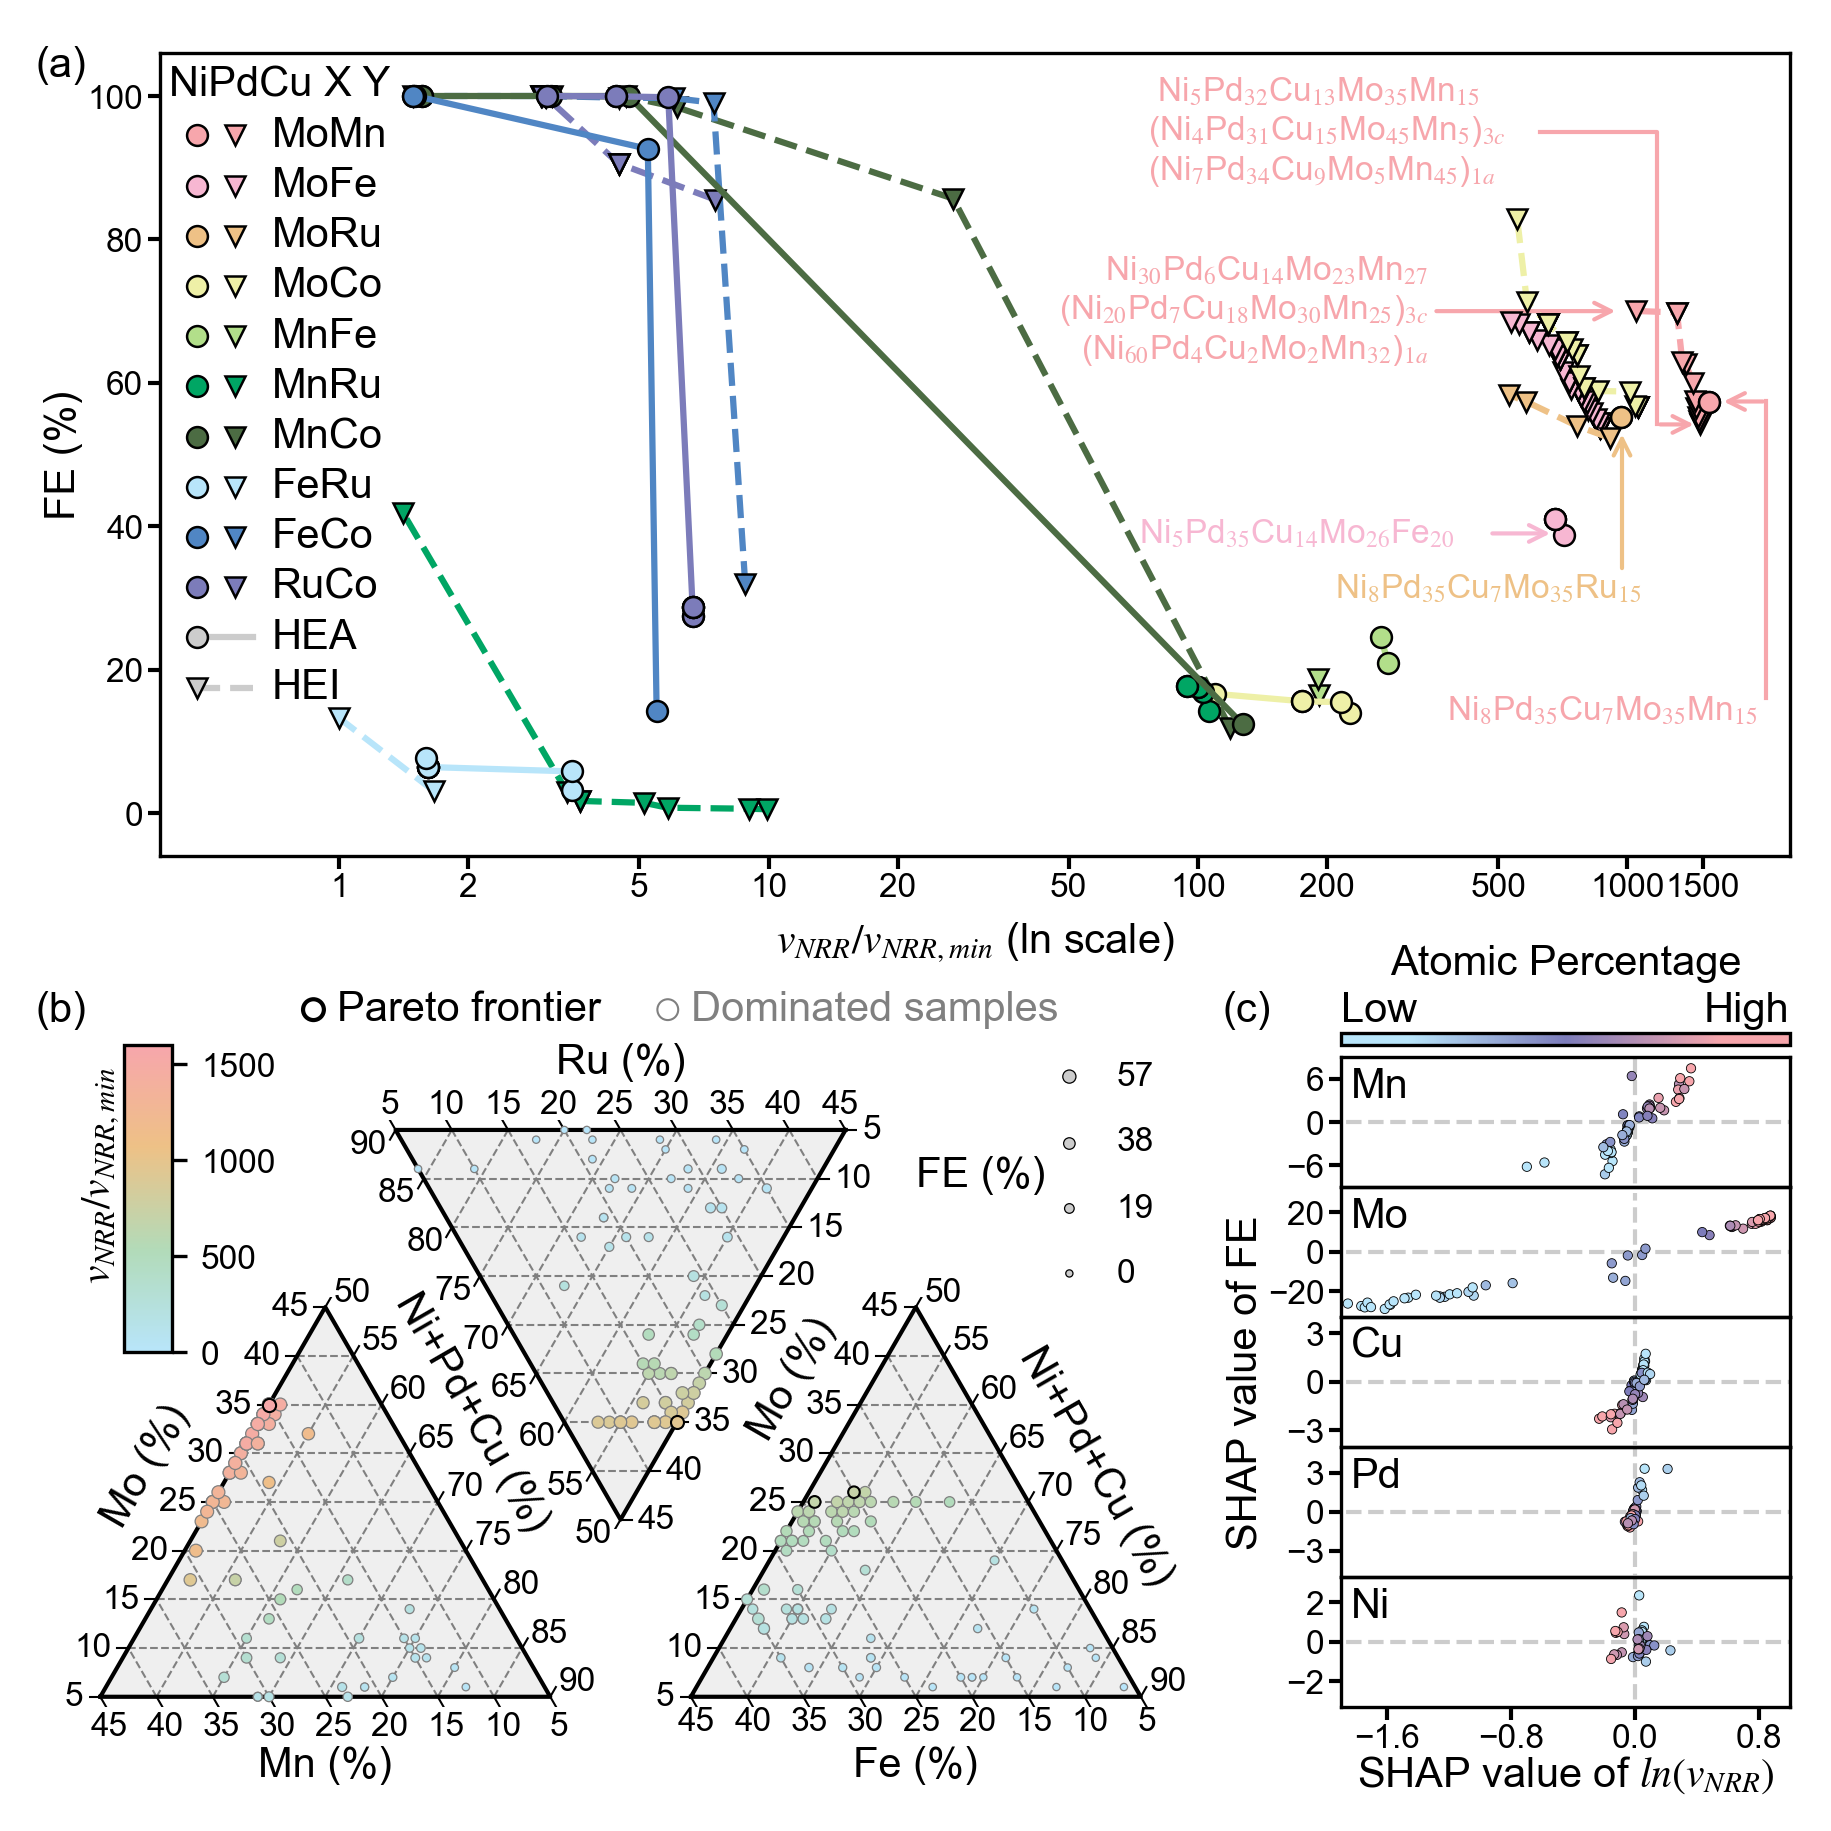

In [15]:
plt.rc('font',family='Arial')
plt.rcParams['mathtext.fontset'] = 'stix'
fig=plt.figure(figsize=(15/2.54, 15/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1]);ax0.set_zorder(5)
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

# Figure aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa
ax1=fig.add_axes([1.1/15, 8.0/15, 13.8/15, 6.8/15])
ax1.set_zorder(2)
ax1.patch.set_alpha(0.0)
ax1.tick_params(length=3,width=1,labelsize=8,pad=1)

for sys in ['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']:
    ax1.plot(pft_HEA[sys][:, 0], pft_HEA[sys][:, 1], c=colors[sys], ls='-', marker='o',  markersize=5, markeredgecolor='k', markeredgewidth=0.6, zorder=2)
    
for sys in ['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']:
    ax1.plot(pft_HEI[sys][:, 0], pft_HEI[sys][:, 1], c=colors[sys], ls='--', marker='v', markersize=5, markeredgecolor='k', markeredgewidth=0.6, zorder=1)

ax1.set_xlabel('$v_{NRR} / v_{NRR, min}$ (ln scale)', fontsize=10)
ax1.set_ylabel('FE (%)', fontsize=10, labelpad=1)
ax1.set_ylim(0.06, -1.06)
ax1.set_yticks([-1, -0.8, -0.6, -0.4, -0.2, 0])
ax1.set_yticklabels([100, 80, 60, 40, 20, 0])
ax1.set_xlim(10, 1.26)
ax1.set_xticks([9.039, 8.346, 7.430, 6.736, 6.043, 5.127, 4.434, 3.741, 2.824, 2.131, 1.726])
ax1.set_xticklabels([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500])

ax1.text(9.95,-1,'NiPdCu X Y', fontsize=10)
for i, sys in enumerate(['MoMn', 'MoFe', 'MoRu', 'MoCo', 'MnFe', 'MnRu', 'MnCo', 'FeRu', 'FeCo', 'RuCo']):
    ax1.plot([9.8], [-1.015+0.07*(i+1)], c=colors[sys], ls='-', marker='o', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
    ax1.plot([9.6], [-1.015+0.07*(i+1)], c=colors[sys], ls='--', marker='v', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
    ax1.text(9.4, -1.015+0.07*(i+1), sys, fontsize=10, va='center')
ax1.plot([9.8, 9.5], [-1.015+0.07*(10+1), -1.015+0.07*(10+1)], c='#CCCCCC', ls='-', )
ax1.plot([9.8], [-1.015+0.07*(10+1)], c='#CCCCCC', ls='-', marker='o', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
ax1.text(9.4, -1.015+0.07*(10+1), 'HEA', fontsize=10, ha='left', va='center')
ax1.plot([9.8, 9.5], [-1.015+0.07*(11+1), -1.015+0.07*(11+1)], c='#CCCCCC', ls='--', )
ax1.plot([9.8], [-1.015+0.07*(11+1)], c='#CCCCCC', ls='-', marker='v', markersize=5, markeredgecolor='k', markeredgewidth=0.6)
ax1.text(9.4, -1.015+0.07*(11+1), 'HEI', fontsize=10, ha='left', va='center')

arrow = FancyArrowPatch((1.36, -0.574), (1.66, -0.574), arrowstyle='->', mutation_scale=10, color=colors['MoMn'], lw=1)
ax1.add_patch(arrow)
ax1.plot([1.39, 1.39], [-0.574, -0.16], c=colors['MoMn'], lw=1, zorder=0)
ax1.text(3.1, -0.13, 'Ni$_8$Pd$_{35}$Cu$_{7}$Mo$_{35}$Mn$_{15}$', fontsize=8, ha='left', c=colors['MoMn'])
arrow = FancyArrowPatch((2.16, -0.33), (2.16, -0.54), arrowstyle='->', mutation_scale=10, color=colors['MoRu'], lw=1)
ax1.add_patch(arrow)
ax1.text(3.7, -0.3, 'Ni$_8$Pd$_{35}$Cu$_{7}$Mo$_{35}$Ru$_{15}$', fontsize=8, ha='left', c=colors['MoRu'])
arrow = FancyArrowPatch((2.9, -0.39), (2.5, -0.39), arrowstyle='->', mutation_scale=10, color=colors['MoFe'], lw=1)
ax1.add_patch(arrow)
ax1.text(4.75, -0.39, 'Ni$_5$Pd$_{35}$Cu$_{14}$Mo$_{26}$Fe$_{20}$', fontsize=8, ha='left', c=colors['MoFe'], va='center')

arrow = FancyArrowPatch((2.0, -0.542), (1.73, -0.542), arrowstyle='->', mutation_scale=10, color=colors['MoMn'], lw=1)
ax1.add_patch(arrow)
ax1.plot([1.97, 1.97, 2.6], [-0.542, -0.95, -0.95], c=colors['MoMn'], lw=1, zorder=0)
ax1.text(4.7, -0.95, ' Ni$_{5}$Pd$_{32}$Cu$_{13}$Mo$_{35}$Mn$_{15}$\n(Ni$_4$Pd$_{31}$Cu$_{15}$Mo$_{45}$Mn$_{5}$)$_{3c}$\n(Ni$_{7}$Pd$_{34}$Cu$_{9}$Mo$_{5}$Mn$_{45}$)$_{1a}$', fontsize=8, ha='left', c=colors['MoMn'], va='center')
arrow = FancyArrowPatch((3.2, -0.70), (2.15, -0.70), arrowstyle='->', mutation_scale=10, color=colors['MoMn'], lw=1, zorder=0)
ax1.add_patch(arrow)
ax1.text(3.2, -0.7, ' Ni$_{30}$Pd$_{6}$Cu$_{14}$Mo$_{23}$Mn$_{27}$\n(Ni$_{20}$Pd$_{7}$Cu$_{18}$Mo$_{30}$Mn$_{25}$)$_{3c}$\n(Ni$_{60}$Pd$_{4}$Cu$_{2}$Mo$_{2}$Mn$_{32}$)$_{1a}$', fontsize=8, ha='right', c=colors['MoMn'], va='center')

# Figure bbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbb
tl=2
th=np.sqrt(3)
# ax1 ===================================================
ax1=fig.add_axes([0.5/15, 0.8/15, 4/15, (4*np.sqrt(3)/2)/15]);ax1.patch.set_alpha(0.0)
ax1.set_xticks([]);ax1.set_yticks([]);ax1.axis('off')
ax1.set_xlim(-tl*0.1,tl*1.1);ax1.set_ylim(-th*0.1,th*1.1)
# ax1.plot([0, tl, tl/2, 0], [0, 0, th, 0], c='k', lw=1)
# scatter
sys = 'MoMn'
pointsN = []
for i, x in enumerate(XN[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsN.append(ternary_to_cartesian(a, b, c))
pointsP = []
for i, x in enumerate(XP[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsP.append(ternary_to_cartesian(a, b, c))
pointsN = np.array(pointsN); pointsP = np.array(pointsP)
ax1.scatter(pointsN[:, 0], pointsN[:, 1], s=smin+(YN[sys][:,1]-sminV)/LsV*Ls, c=YN[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='grey', lw=0.3, alpha=1, zorder=10)
ax1.scatter(pointsP[:, 0], pointsP[:, 1], s=smin+(YP[sys][:,1]-sminV)/LsV*Ls, c=YP[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='k', lw=0.5, alpha=1, zorder=11)
# draw line
itl=0.40; ia_up=0.45; ib_low=0.05; sp=[2-(2*ia_up)-ib_low, ib_low*np.sqrt(3)]
ax1.plot([0+sp[0], tl*itl+sp[0], tl/2*itl+sp[0], 0+sp[0]], [0+sp[1], 0+sp[1], th*itl+sp[1], 0+sp[1]], c='k', lw=1, zorder=6)
ia_up = ia_up; ia_low = ia_up - itl; ib_low = ib_low; ib_up = ib_low + itl; ic_up = 1-(ib_low+ia_low); ic_low = ic_up - itl
a5i = find_multiple_of_5(int(ia_low*100), int(ia_up*100))
for i in a5i:
    aa = itl-(i/100-ia_low)
    ax1.plot([sp[0]+aa*tl, sp[0]+aa], [sp[1], sp[1]+aa*th], lw=0.5, ls='--', c='grey')
    ax1.plot([sp[0]+aa*tl, sp[0]+aa*tl+0.01], [sp[1], sp[1]-0.01*th], lw=0.5, c='k')
    ax1.text(sp[0]+aa*tl+0.015, sp[1]-0.015*th, str(i), fontsize=8, ha='center', va='top')
b5i = find_multiple_of_5(int(ib_low*100), int(ib_up*100))
for i in b5i:
    bb = i/100 - ib_low
    ax1.plot([sp[0]+bb, sp[0]+tl*itl-bb], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, ls='--', c='grey')
    ax1.plot([sp[0]+bb, sp[0]+bb-tl*0.01], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, c='k')
    ax1.text(sp[0]+bb-tl*0.015, sp[1]+th*bb, str(i), ha='right', va='center', fontsize=8)
c5i = find_multiple_of_5(int(ic_low*100), int(ic_up*100))
for i in c5i:
    cc1 = i/100 - ic_low; cc2 = ic_up - i/100
    ax1.plot([sp[0]+cc1*tl, sp[0]+cc1*tl+cc2], [sp[1], sp[1]+th*cc2], lw=0.5, ls='--', c='grey')
    ax1.plot([sp[0]+cc1*tl+cc2, sp[0]+cc1*tl+cc2+0.01*tl/2], [sp[1]+th*cc2, sp[1]+th*(cc2+0.01)], lw=0.5, c='k')
    ax1.text(sp[0]+cc1*tl+cc2+0.015*tl/2, sp[1]+th*(cc2+0.015), str(i), fontsize=8, ha='left', va='center')
# other
ax1.set_xlim(sp[0]-tl*0.01, sp[0]+tl*0.41)
ax1.set_ylim(sp[1]-th*0.01, sp[1]+th*0.41)
ax1.text(sp[0]+tl*itl/2, sp[1]-th*0.05, 'Mn (%)', fontsize=10, ha='center', va='top')
ax1.text(sp[0]+tl*itl/4-th*0.055*tl/th-0.01, sp[1]+th*itl/2+th*0.055/th+0.01, 'Mo (%)', fontsize=10, ha='center', va='center', rotation=60)
ax1.text(sp[0]+tl*itl*3/4+th*0.05*tl/th-0.04, sp[1]+th*itl/2+th*0.05/th+0.11, 'Ni+Pd+Cu (%)', fontsize=10, ha='center', va='center', rotation=-60)
ax1.add_patch(Polygon([[0+sp[0], 0+sp[1]], [tl*itl+sp[0], 0+sp[1]], [tl/2*itl+sp[0], th*itl+sp[1]]], facecolor='#CCCCCC', alpha=0.3, linewidth=0))

# ax2 ===================================================
ax2=fig.add_axes([3/15, 2.3/15, 4/15, (4*np.sqrt(3)/2)/15]);ax2.patch.set_alpha(0.0)
ax2.set_xticks([]);ax2.set_yticks([]);ax2.axis('off')
ax2.set_xlim(-tl*0.1,tl*1.1);ax2.set_ylim(-th*0.1,th*1.1)
# ax2.plot([0, tl, tl/2, 0], [0, 0, th, 0], c='k', lw=1)
# scatter
sys = 'MoRu'
pointsN = []
for i, x in enumerate(XN[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsN.append(ternary_to_cartesian(a, b, c))
pointsP = []
for i, x in enumerate(XP[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsP.append(ternary_to_cartesian(a, b, c))
pointsN = np.array(pointsN); pointsP = np.array(pointsP)
ax2.scatter(pointsN[:, 0], pointsN[:, 1], s=smin+(YN[sys][:,1]-sminV)/LsV*Ls, c=YN[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='grey', lw=0.3, alpha=1, zorder=10)
ax2.scatter(pointsP[:, 0], pointsP[:, 1], s=smin+(YP[sys][:,1]-sminV)/LsV*Ls, c=YP[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='k', lw=0.5, alpha=1, zorder=11)
# draw line
itl=0.40; ia_up=0.45; ib_low=0.05; sp=[2-(2*ia_up)-ib_low, ib_low*np.sqrt(3)]
ax2.plot([0+sp[0], tl*itl+sp[0], tl/2*itl+sp[0], 0+sp[0]], [0+sp[1], 0+sp[1], th*itl+sp[1], 0+sp[1]], c='k', lw=1, zorder=6)
ia_up = ia_up; ia_low = ia_up - itl; ib_low = ib_low; ib_up = ib_low + itl; ic_up = 1-(ib_low+ia_low); ic_low = ic_up - itl
a5i = find_multiple_of_5(int(ia_low*100), int(ia_up*100))
for i in a5i:
    aa = itl-(i/100-ia_low)
    ax2.plot([sp[0]+aa*tl, sp[0]+aa], [sp[1], sp[1]+aa*th], lw=0.5, ls='--', c='grey')
    ax2.plot([sp[0]+aa*tl, sp[0]+aa*tl+0.01], [sp[1], sp[1]-0.01*th], lw=0.5, c='k')
    ax2.text(sp[0]+aa*tl+0.01, sp[1]-0.01*th, str(i), fontsize=8, ha='center', va='bottom')
b5i = find_multiple_of_5(int(ib_low*100), int(ib_up*100))
for i in b5i:
    bb = i/100 - ib_low
    ax2.plot([sp[0]+bb, sp[0]+tl*itl-bb], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, ls='--', c='grey')
    ax2.plot([sp[0]+bb, sp[0]+bb-tl*0.01], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, c='k')
    ax2.text(sp[0]+bb-tl*0.015, sp[1]+th*bb, str(i), ha='left', va='center', fontsize=8)
c5i = find_multiple_of_5(int(ic_low*100), int(ic_up*100))
for i in c5i:
    cc1 = i/100 - ic_low; cc2 = ic_up - i/100
    ax2.plot([sp[0]+cc1*tl, sp[0]+cc1*tl+cc2], [sp[1], sp[1]+th*cc2], lw=0.5, ls='--', c='grey')
    ax2.plot([sp[0]+cc1*tl+cc2, sp[0]+cc1*tl+cc2+0.01*tl/2], [sp[1]+th*cc2, sp[1]+th*(cc2+0.01)], lw=0.5, c='k')
    ax2.text(sp[0]+cc1*tl+cc2+0.015*tl/2, sp[1]+th*(cc2+0.015), str(i), fontsize=8, ha='right', va='center')
# other
ax2.set_xlim(sp[0]+tl*0.41, sp[0]-tl*0.01)
ax2.set_ylim(sp[1]+th*0.41, sp[1]-th*0.01)
ax2.text(sp[0]+tl*itl/2, sp[1]-th*0.09, 'Ru (%)', fontsize=10, ha='center', va='top')
# ax2.text(sp[0]+tl*itl/4-th*0.05*tl/th, sp[1]+th*itl/2+th*0.05/th, 'Mo (%)', fontsize=8, ha='center', va='center', rotation=60)
# ax2.text(sp[0]+tl*itl*3/4+th*0.05*tl/th, sp[1]+th*itl/2+th*0.05/th, 'Ni+Pd+Cu (%)', fontsize=8, ha='center', va='center', rotation=-60)
ax2.add_patch(Polygon([[0+sp[0], 0+sp[1]], [tl*itl+sp[0], 0+sp[1]], [tl/2*itl+sp[0], th*itl+sp[1]]], facecolor='#CCCCCC', alpha=0.3, linewidth=0))

# ax3 ===================================================
ax3=fig.add_axes([5.5/15, 0.8/15, 4/15, (4*np.sqrt(3)/2)/15]);ax3.patch.set_alpha(0.0)
ax3.set_xticks([]);ax3.set_yticks([]);ax3.axis('off')
ax3.set_xlim(-tl*0.1,tl*1.1);ax3.set_ylim(-th*0.1,th*1.1)
# ax2.plot([0, tl, tl/2, 0], [0, 0, th, 0], c='k', lw=1)
# scatter
sys = 'MoFe'
pointsN = []
for i, x in enumerate(XN[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsN.append(ternary_to_cartesian(a, b, c))
pointsP = []
for i, x in enumerate(XP[sys]):
    a = x[4]; b = x[3]; c = 1 - a - b; pointsP.append(ternary_to_cartesian(a, b, c))
pointsN = np.array(pointsN); pointsP = np.array(pointsP)
ax3.scatter(pointsN[:, 0], pointsN[:, 1], s=smin+(YN[sys][:,1]-sminV)/LsV*Ls, c=YN[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='grey', lw=0.3, alpha=1, zorder=10)
ax3.scatter(pointsP[:, 0], pointsP[:, 1], s=smin+(YP[sys][:,1]-sminV)/LsV*Ls, c=YP[sys][:, 0], vmin=vmin, vmax=vmax, cmap=cus_cmap, ec='k', lw=0.5, alpha=1, zorder=11)
# draw line
itl=0.40; ia_up=0.45; ib_low=0.05; sp=[2-(2*ia_up)-ib_low, ib_low*np.sqrt(3)]
ax3.plot([0+sp[0], tl*itl+sp[0], tl/2*itl+sp[0], 0+sp[0]], [0+sp[1], 0+sp[1], th*itl+sp[1], 0+sp[1]], c='k', lw=1, zorder=6)
ia_up = ia_up; ia_low = ia_up - itl; ib_low = ib_low; ib_up = ib_low + itl; ic_up = 1-(ib_low+ia_low); ic_low = ic_up - itl
a5i = find_multiple_of_5(int(ia_low*100), int(ia_up*100))
for i in a5i:
    aa = itl-(i/100-ia_low)
    ax3.plot([sp[0]+aa*tl, sp[0]+aa], [sp[1], sp[1]+aa*th], lw=0.5, ls='--', c='grey')
    ax3.plot([sp[0]+aa*tl, sp[0]+aa*tl+0.01], [sp[1], sp[1]-0.01*th], lw=0.5, c='k')
    ax3.text(sp[0]+aa*tl+0.01, sp[1]-0.01*th, str(i), fontsize=8, ha='center', va='top')
b5i = find_multiple_of_5(int(ib_low*100), int(ib_up*100))
for i in b5i:
    bb = i/100 - ib_low
    ax3.plot([sp[0]+bb, sp[0]+tl*itl-bb], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, ls='--', c='grey')
    ax3.plot([sp[0]+bb, sp[0]+bb-tl*0.01], [sp[1]+th*bb, sp[1]+th*bb], lw=0.5, c='k')
    ax3.text(sp[0]+bb-tl*0.015, sp[1]+th*bb, str(i), ha='right', va='center', fontsize=8)
c5i = find_multiple_of_5(int(ic_low*100), int(ic_up*100))
for i in c5i:
    cc1 = i/100 - ic_low; cc2 = ic_up - i/100
    ax3.plot([sp[0]+cc1*tl, sp[0]+cc1*tl+cc2], [sp[1], sp[1]+th*cc2], lw=0.5, ls='--', c='grey')
    ax3.plot([sp[0]+cc1*tl+cc2, sp[0]+cc1*tl+cc2+0.01*tl/2], [sp[1]+th*cc2, sp[1]+th*(cc2+0.01)], lw=0.5, c='k')
    ax3.text(sp[0]+cc1*tl+cc2+0.015*tl/2, sp[1]+th*(cc2+0.015), str(i), fontsize=8, ha='left', va='center')
# other
ax3.set_xlim(sp[0]-tl*0.01, sp[0]+tl*(0.01+itl))
ax3.set_ylim(sp[1]-th*0.01, sp[1]+th*(0.01+itl))
ax3.text(sp[0]+tl*itl/2, sp[1]-th*0.05, 'Fe (%)', fontsize=10, ha='center', va='top')
ax3.text(sp[0]+tl*itl/4-th*0.06*tl/th+0.1, sp[1]+th*itl/2+th*0.06/th+0.16, 'Mo (%)', fontsize=10, ha='center', va='center', rotation=60)
ax3.text(sp[0]+tl*itl*3/4+th*0.055*tl/th+0.01, sp[1]+th*itl/2+th*0.055/th+0.01, 'Ni+Pd+Cu (%)', fontsize=10, ha='center', va='center', rotation=-60)
ax3.add_patch(Polygon([[0+sp[0], 0+sp[1]], [tl*itl+sp[0], 0+sp[1]], [tl/2*itl+sp[0], th*itl+sp[1]]], facecolor='#CCCCCC', alpha=0.3, linewidth=0))

# colorbar
cax = fig.add_axes([0.8/15, 3.8/15, 0.4/15, 2.6/15])
cb = ColorbarBase(cax, cmap=cus_cmap,norm=Normalize(vmin=vmin, vmax=vmax))
cb.ax.tick_params(labelsize=8)
cax_label = fig.add_axes([0.6/15, 4/15, 0.01/15, 2.6/15])
cax_label.axis('off')
cax_label.text(0, 0.5,'$v_{NRR}/v_{NRR,min}$',fontsize=10, rotation=90, ha='center', va='center')
# size bar
axs = fig.add_axes([8.6/15, 4.3/15, 0.4/15, 2./15])
axs.axis('off'); axs.set_xlim(0, 0.4); axs.set_ylim(-0.1, 1.1)
axs.scatter([0.2, 0.2, 0.2, 0.2], [0, 0.33, 0.66, 1], s=[3, 5.33, 7.67, 10], lw=0.3, ec='k', c='#CCCCCC')
axs.text(0, 0.5, 'FE (%)', fontsize=10, ha='right', va='center')
axs.text(0.6, 0, '0', fontsize=8, ha='left', va='center')
axs.text(0.6, 0.33, '19', fontsize=8, ha='left', va='center')
axs.text(0.6, 0.67, '38', fontsize=8, ha='left', va='center')
axs.text(0.6, 1, '57', fontsize=8, ha='left', va='center')

# Figure ccccccccccccccccccccccccccccccc
cmap_fv=LinearSegmentedColormap.from_list(name='xx', colors=list(zip([0, 0.15, 0.5, 0.85, 1], ['#B8E5FA', '#B8E5FA', '#7C7CBA', '#F7A6AC', '#F7A6AC'])))

sys = 'MoMn'
all_xlim=(-1.9, 1.0)

ax1=fig.add_axes([11.1/15, 0.8/15, 3.8/15, 1.1/15]); ax1.tick_params(length=3,width=1,labelsize=8,pad=1);ax1.patch.set_alpha(0.0)
ax1.set_xlabel('SHAP value of $ln(v_{NRR})$', fontsize=10, labelpad=0)
ax1.scatter(shap_objs_lnv[sys].values[:, 0], shap_objs_FE[sys].values[:, 0], c=shap_objs_FE[sys].data[:, 0], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax1.get_ylim()
ax1.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax1.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax1.set_xlim(*all_xlim); ax1.set_ylim(*ylim); ax1.set_xticks([-1.5, -1, -0.5, 0, 0.5])
ax1.set_yticks([-2, 0, 2]); ax1.set_ylim(-3.3, 3.3)
ax1.set_xticks([-1.6, -0.8, 0, 0.8])

ax2=fig.add_axes([11.1/15, 1.9/15, 3.8/15, 1.1/15]); ax2.tick_params(length=3,width=1,labelsize=8,pad=1); ax2.set_xticks([]);ax2.patch.set_alpha(0.0)
ax2.scatter(shap_objs_lnv[sys].values[:, 1], shap_objs_FE[sys].values[:, 1], c=shap_objs_FE[sys].data[:, 1], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax2.get_ylim()
ax2.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax2.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax2.set_xlim(*all_xlim); ax2.set_ylim(*ylim)
ax2.set_yticks([3, 0, -3]); ax2.set_ylim(-5,5)

ax3=fig.add_axes([11.1/15, 3.0/15, 3.8/15, 1.1/15]); ax3.tick_params(length=3,width=1,labelsize=8,pad=1); ax3.set_xticks([]);ax3.patch.set_alpha(0.0)
ax3.scatter(shap_objs_lnv[sys].values[:, 2], shap_objs_FE[sys].values[:, 2], c=shap_objs_FE[sys].data[:, 2], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax3.get_ylim()
ax3.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax3.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax3.set_xlim(*all_xlim); ax3.set_ylim(*ylim)
ax3.set_yticks([-3, 0, 3]); ax3.set_ylim(-4, 4)
ax3.set_ylabel('SHAP value of FE', fontsize=10, labelpad=5)

ax4=fig.add_axes([11.1/15, 4.1/15, 3.8/15, 1.1/15]); ax4.tick_params(length=3,width=1,labelsize=8,pad=1); ax4.set_xticks([]);ax4.patch.set_alpha(0.0)
ax4.scatter(shap_objs_lnv[sys].values[:, 3], shap_objs_FE[sys].values[:, 3], c=shap_objs_FE[sys].data[:, 3], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax4.get_ylim()
ax4.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax4.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax4.set_xlim(*all_xlim); ax4.set_ylim(*ylim)
ax4.set_yticks([-20, 0, 20]); ax4.set_ylim(-33, 33)

ax5=fig.add_axes([11.1/15, 5.2/15, 3.8/15, 1.1/15]); ax5.tick_params(length=3,width=1,labelsize=8,pad=1); ax5.set_xticks([]);ax5.patch.set_alpha(0.0)
ax5.scatter(shap_objs_lnv[sys].values[:, 4], shap_objs_FE[sys].values[:, 4], c=shap_objs_FE[sys].data[:, 4], cmap=cmap_fv, ec='k', lw=0.2, s=5)
ylim=ax5.get_ylim()
ax5.plot([0, 0], [-30, 30], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax5.plot([-30, 30], [0, 0], lw=1, c='#CCCCCC', ls='--', zorder=0)
ax5.set_xlim(*all_xlim); ax5.set_ylim(*ylim)
ax5.set_yticks([-6, 0, 6]); ax5.set_ylim(-9, 9)

ax6=fig.add_axes([11.1/15, 6.4/15, 3.8/15, 0.1/15])
cb = ColorbarBase(ax6, cmap=cmap_fv, orientation='horizontal')
cb.set_ticks([])

ax0.scatter([2.4/15], [6.7/15], s=25, c='none', ec='k', lw=1)
ax0.text(2.6/15, 6.7/15, 'Pareto frontier ', fontsize=10, ha='left', va='center')
ax0.scatter([5.4/15], [6.7/15], s=25, c='none', ec='grey', lw=0.5)
ax0.text(5.6/15, 6.7/15, 'Dominated samples', fontsize=10, ha='left', va='center', c='grey')

ax0.text((11.1+3.8/2)/15, 7/15, 'Atomic Percentage', fontsize=10, ha='center')
ax0.text((11.1)/15, 6.6/15, 'Low', fontsize=10, ha='left')
ax0.text((11.1+3.8)/15, 6.6/15, 'High', fontsize=10, ha='right')
ax0.text((11.1+0.1*8.5/10)/15, (1.1+1.1*0.5)/15, 'Ni', fontsize=10, ha='left', va='center')
ax0.text((11.1+0.1*8.5/10)/15, (1.1+1.1*1.5)/15, 'Pd', fontsize=10, ha='left', va='center')
ax0.text((11.1+0.1*8.5/10)/15, (1.1+1.1*2.5)/15, 'Cu', fontsize=10, ha='left', va='center')
ax0.text((11.1+0.1*8.5/10)/15, (1.1+1.1*3.5)/15, 'Mo', fontsize=10, ha='left', va='center')
ax0.text((11.1+0.1*8.5/10)/15, (1.1+1.1*4.5)/15, 'Mn', fontsize=10, ha='left', va='center')

#
ax0.text(0.05/15, 14.6/15, '(a)', fontsize=10)
ax0.text(0.05/15, 6.6/15, '(b)', fontsize=10)
ax0.text(10.1/15, 6.6/15, '(c)', fontsize=10)

# plt.show()
# fig.savefig('Figure_4.tif',dpi=300)